In [6]:
from scipy.signal import butter, freqz, lfilter
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import numpy as np
from scipy import signal
from IPython.display import Audio

## Άσκηση - σχεδίαση φίλτρων στο χώρο του Laplace

Εργάζεστε σε μια νεοφυή (startup) επιχείρηση ως $\textrm{μηχανικός σχεδίασης ϕίλτρων}$.

Ο προϊστάμενός σας συγκαλεί σύσκεψη στην οποία αποφασίζεται ότι εσείς πρέπει να σχεδιάσετε και να αναπτύξετε ένα ΓΧΑ σύστημα με απόκριση συχνότητας $H(f)$ για εφαρμογές επικοινωνίας ϕωνής, το οποίο θα αποκόπτει τις συχνότητες μεγαλύτερες από κάποια δοθείσα $f_c$ (η οποία λέγεται, όπως ξέρετε, συχνότητα αποκοπής - cut-off frequency) ενώ ϑα κρατά όσο γίνεται ανέπαφες τις συχνότητες μικρότερες από $f_c$. Τέτοια συστήματα γνωρίζετε ότι ονομάζονται $\textbf{ϕίλτρα επιλογής συχνοτήτων}$, και για αυτήν την άσκηση θα τα αποκαλούμε απλά ως ϕίλτρα.

Ο προϊστάμενός σας, που δε γνωρίζει θεωρία σημάτων και συστημάτων (ενώ εσείς πλέον είστε ξεφτέρια! 😃), σας παραδίδει την απόκριση συχνότητας $H(f)$ που θέλει να ϕτιάξετε, στο παρακάτω σχήμα, και σας αναφέρει ότι το ζητούμενο $f_c$ ισούται με $f_c = 3000$ Hz, αφού το ϕίλτρο θα ενσωματωθεί σε αμυντικά ασύρματα τηλεφωνικά συστήματα, όπου το εύρος ζώνης επικοινωνίας - και το κόστος λειτουργίας - είναι περιορισμένο, καθώς σημασία έχει να είναι απλά καταληπτή η επικοινωνία και όχι η ποιότητά της.

<p style="text-align: center"><img src="./files/LP.png" alt="Lowpass" width="600"/></p>

**(α')** Γράψτε στο παρακάτω κελί (κάνοντας double click πάνω του) την εξήγηση που θα δώσετε στον προϊστάμενό σας σχετικά με το αδύνατο της πραγματοποίησης του παραπάνω φίλτρου!

### Απάντηση:

Η κρουστική απόκριση του ιδανικού χαμηλοπερατού φίλτρου είναι άπειρης διάρκειας και μη αιτιατή (συνάρτηση $\textrm{sinc}()$.)


**(β')** Αφού τον πείσατε για την ορθότητα του παραπάνω ερωτήματος, σας αναθέτει να υλοποιήσετε ένα φίλτρο που να πλησιάζει όσο γίνεται αυτό που σας ζήτησε αρχικά, και να είναι υλοποιήσιμο. 
Στην προσπάθειά σας αυτή, αναζητείτε μια συνάρτηση που να ταιριάζει στις "προδιαγραφές" σας. Ένας μαθηματικός φίλος σας αναφέρει ότι έχει υπόψη του μια συνάρτηση η οποία να πλησιάζει το ζητούμενο φίλτρο σας, και την οποία σχεδιάζει πρόχειρα στο χαρτί, όπως στο παρακάτω σχήμα. 


<p style="text-align: center"><img src="./files/butter2.png" alt="Butterworth" width="600"/></p>

Η συνάρτηση ονομάζεται

### $$\text{συνάρτηση Butterworth}$$

Μη έχοντας καλύτερη εναλλακτική, του ζητάτε να σας δώσει τη μαθηματική περιγραφή της συνάρτησης. Σας δίνει μια περιγραφή στο χώρο της συχνότητας που βρήκε σε κάποιο μαθηματικό εγχειρίδιο, ως

$$\large |f(x)|^2 = \displaystyle \frac{1}{1 + \left(\frac{x}{x_c}\right)^{2N}}$$

την οποία εσείς προσαρμόζετε στις ανάγκες σας ως

$$\large |H(f)|^2 = \displaystyle \frac{1}{1 + \left(\frac{j2\pi f}{j2\pi f_c}\right)^{2N}}$$

με $N$ την **τάξη** της συνάρτησης, όπως σας ανέφερε. 

Προσέξτε ότι σας δίνει μια περίγραφή της απόκρισης πλάτους **στο τετράγωνο** (δεν ήταν και ιδιαίτερα βοηθητικός, μάλλον βαριόταν 😄)... ιδανικά θα θέλαμε τη συνάρτηση $H(f)$, ας δούμε όμως τι μπορούμε να κάνουμε.

$\LARGE \rightarrow$ Μετατρέψτε τη συνάρτηση αυτή στο χώρο του μετασχ. Laplace (βρείτε δηλ. το $|H(s)|^2$) θέτοντας $s = j2\pi f$.

**Γράψτε την απάντησή σας παρακάτω:**

### Απάντηση:

$$\large |H(s)|^2 = \frac{1}{1 + \left(\frac{s}{j2\pi f_c}\right)^{2N}}$$

**(γ')** Θέλετε να μελετήσετε τη συμπεριφορά του φίλτρου - όπως το ονομάζετε πλέον - Butterworth, για να το κατανοήσετε καλύτερα. 

$\LARGE \rightarrow$ Βρείτε τους πόλους του $|H(s)|^2$ στο $s$-επίπεδο.

**Γράψτε την απάντησή σας παρακάτω:**

$\underline{Βοήθεια:}$
Πολλαπλασιάστε την απάντησή σας στο προηγ. ερώτημα σε αριθμητή και παρονομαστή με το $(j2\pi f_c)^{2N}$ και βρείτε τις ρίζες του παρονομαστή, χρησιμοποιώντας τη μεθοδολογία του De Moivre από την πρώτη κιόλας διάλεξη του μαθήματος. 

### Απάντηση: 

Οι πόλοι $s_k$ είναι οι $$\large s_k = (2\pi f_c) e^{j\pi \left(\frac{2k+N-1}{2N}\right)}$$

για $k=0,1,\cdots,2N-1$.

Ας τους απεικονίσουμε για κάποια τιμή του $N$, έστω $N=8$, και $f_c=1000$ Hz, ώστε να καταλάβουμε εποπτικά τι συμβαίνει.

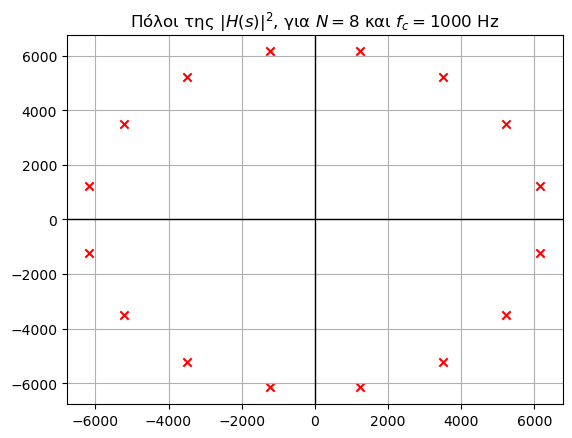

In [7]:
# Αρχικοποιούμε κάποιες μεταβλητές
fc = 1000
N = 8
wc = 2*np.pi*fc

# Η συνάρτηση μεταφοράς |H(s)|^2 με χρήση συντελεστών των όρων της
b = [(1j*wc)**(2*N)]
a = [1, *np.zeros(2*N - 1), (1j*wc)**(2*N)]

# Χρησιμοποιούμε την έτοιμη συνάρτηση tf2zpk του πακέτου scipy.signal
zeros, poles, gain = signal.tf2zpk(b, a)

# Απεικονίζουμε
plt.scatter(poles.real, poles.imag, marker='x', color='red', label='Poles')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Πόλοι της $|H(s)|^2$, για $N=8$ και $f_c=1000$ Hz')   # Ομορφαίνουμε
plt.grid()                                                       # Ομορφαίνουμε               
plt.show() 

**(δ')** Γνωρίζετε από τη θεωρία σας ότι επειδή το φίλτρο σας έχει πραγματική κρουστική απόκριση (δηλ. $h(t) \in \mathbb{R}$), θα ισχύουν οι γνωστές συμμετρίες στο χώρο του Fourier, δηλ.

$$H(-f) = H^*(f)$$

Με χρήση αυτής, μπορούμε να γράψουμε

$$|H(f)|^2 = H(f)H^*(f) = H(f)H(-f) = H(s)H(-s)\Big|_{s=j2\pi f}$$

Άρα οι πόλοι που βρήκατε νωρίτερα στο χαρτί σας (και απεικονίσατε για κάποια τυχαία $N, f_c$) ανήκουν στο *σύνθετο* σύστημα $$|H(s)|^2 = H(s)H(-s)$$ 

Καταλαβαίνετε ότι κάποιοι πόλοι από αυτούς θα ανήκουν στο $H(s)$ και οι υπόλοιποι στο $H(-s)$, δεδομένου ότι έχουμε γινόμενο συναρτήσεων μεταφοράς. Το σύνολο των πόλων που έχετε βρει θα είναι η ένωση των συνόλων των πόλων των δυο συστημάτων, $H(s)$ και $H(-s)$.

Έχοντας βρει τους πόλους από το προηγούμενο ερώτημα, και με τη βοήθεια της απεικόνισης παραπάνω, επιλέξτε από τους πόλους που σχεδιάσατε ένα υποσύνολο πόλων που θα ανήκει στο $H(s)$, ώστε το σύστημα που θα προκύψει από αυτούς να είναι $\textbf{ευσταθές και αιτιατό}$. 

Προσέξτε ότι αν $s_p$ είναι ένας πόλος του $H(s)$, τότε ο $-s_p$ είναι $\textbf{αναγκαστικά}$ πόλος του $H(-s)$. Επίσης, ένας πόλος $s_p$ θα ανήκει είτε στο ένα σύστημα είτε στο άλλο, και όχι και στα δυο ταυτόχρονα. Τέλος, θυμηθείτε ότι $h(t) \in \mathbb{R}$, οπότε πρέπει να γνωρίζετε κάτι ακόμα για τους πόλους της συνάρτησης μεταφοράς τέτοιων σημάτων, και τον τρόπο που εμφανίζονται στο μιγαδικό επίπεδο (ως ζεύγος...... ?).

$\LARGE \rightarrow$ Ποιούς πόλους επιλέξατε από το $|H(s)|^2$ για το $H(s)$, και γιατί? Απαντήσετε παρακάτω:

**(μην περιγράψετε αριθμητικά τους πόλους - περιγράψτε τους ως προς τη θέση τους στο μιγαδικό επίπεδο)**

### Απάντηση:

Επέλεξα όλους τους πόλους στο αριστερό μιγαδικό ημιεπίπεδο, έτσι ώστε το σύστημα να είναι ευσταθές και αιτιατό αλλά και πραγματικό. Δηλ.

$$Poles = \{s_k : \Re\{s_k\} < 0\}$$

για $k=0,1,\cdots,N-1$.

**(ε')** Επιστρέφοντας στη θεωρία του φίλτρου Butterworth... θα χρειαστούμε τους πόλους που βρήκατε στο ερώτημα **(γ')**. Παρατηρήστε ότι

$$|H(s)|^2 \Big|_{s=0} = H(s)H(-s)\Big|_{s=0} = 1$$

και ότι

$$|H(s)|^2 = H(s)H(-s) = \frac{(j2\pi f_c)^{2N}}{\prod_{k=0}^{N-1}(s+s_k)\prod_{l=0}^{N-1}(s+s_l)}$$

με τον παρονομαστή να αφορά τους πόλους του $H(s)$ και του $H(-s)$, αντίστοιχα.

$\LARGE \rightarrow$ Υπολογίστε σε ένα πρόχειρο χαρτί το $H(s)$ για $N=1$ και $N=2$, βρίσκοντας το $|H(s)|^2$ από την παραπάνω σχέση και διαχωρίζοντας τα $H(s)$, $H(-s)$ με βάση την απαίτηση το $H(s)$ να είναι $\textbf{ευσταθές και αιτιατό}$.

$\underline{Βοήθεια:}$
Πρέπει να βρείτε: $$\displaystyle H_{N=1}(s) = \frac{2\pi f_c}{s + 2\pi f_c} , \: \: H_{N=2}(s) = \frac{(2\pi f_c)^2}{(s + 2\pi f_c e^{j3\pi/4})(s + 2\pi f_c e^{j5\pi/4})}$$

**(στ)** Εν τέλει, πώς θα υλοποιούσαμε το φίλτρο Butterworth στην πραγματικότητα? Ένας τρόπος είναι μέσω μιας διαφορικής εξίσωσης που μοντελοποιεί ένα ηλεκτρικό κύκλωμα! 

$\LARGE \rightarrow$ Βρείτε τη διαφορική εξίσωση $\textit{δευτέρας τάξης}$ (δηλ. για $N=2$) που αντιστοιχεί στο φίλτρο Butterworth που βρήκατε παραπάνω, χρησιμοποιώντας συχνότητα αποκοπής $f_c = \frac{1}{2\pi}$ Hz, και γράψτε τους συντελεστές κάθε όρου της παρακάτω:

### Απάντηση:
1. Συντελεστής του $y(t) = 1 $
2. Συντελεστής του $y'(t) = \sqrt{2} $
3. Συντελεστής του $y''(t) = 1$
4. Συντελεστής του $x(t) = 1$

**(ζ)** Υλοποιήστε στην ``Python`` την απόκριση πλάτους $|H(f)|$ του φίλτρου σας για $f_c = 3000$ Hz, δειγματοληπτώντας έναν άξονα συχνοτήτων $f$ στο διάστημα $[-5000, 5000]$ ανά $Df = 0.1$ Hz, για 
- $N=6$, 
- $N=16$,
- $N=46$. 

Για αυτό το ερώτημα, συμπληρώστε τον παρακάτω κώδικα:

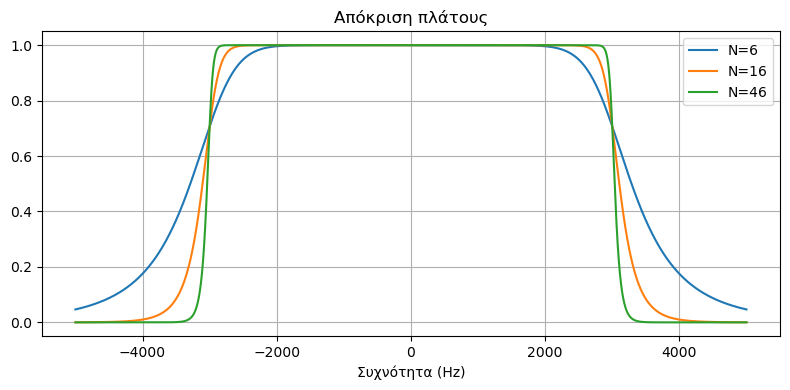

In [8]:
f = np.arange(start=-5000, stop=5000, step=0.1)           # Άξονας συχνοτήτων
fc = 3000                                                 # Συχνότητα αποκοπής

N = 6
H1 = np.sqrt(np.abs(1 / (1 + (f/fc)**(2*N)))) # INSERT CODE HERE - υλοποιήστε το φίλτρο |H(f)| για N=6
N = 16
H2 = np.sqrt(np.abs(1 / (1 + (f/fc)**(2*N)))) # INSERT CODE HERE - υλοποιήστε το φίλτρο |H(f)| για N=16
N = 46
H3 = np.sqrt(np.abs(1 / (1 + (f/fc)**(2*N)))) # INSERT CODE HERE - υλοποιήστε το φίλτρο |H(f)| για N=46


plt.figure(figsize=(8,4))    # Γράφημα

plt.plot(f, np.abs(H1))       # Το πρώτο φίλτρο (βάζουμε np.abs γιατί προκύπτουν πολύ πολύ μικρά φανταστικά μέρη)
plt.plot(f, np.abs(H2))       # Το δεύτερο
plt.plot(f, np.abs(H3))       # και το τρίτο

plt.title('Απόκριση πλάτους')            # Ομορφαίνουμε
plt.xlabel('Συχνότητα (Hz)')             # Ομορφαίνουμε
plt.grid(True)                           # Ομορφαίνουμε
plt.legend(['N=6', 'N=16', 'N=46'])      # Ομορφαίνουμε
plt.tight_layout()
plt.show()

**(η')** Τι παρατηρείτε στο φίλτρο σας όσο αυξάνεται η τάξη του, $N$? Γράψτε παρακάτω την απάντησή σας:

### Απάντηση:

Το φίλτρο γίνεται πιο αυστηρό στη συχνότητα αποκοπής του, δηλ. η μετάβαση γύρω από τη συχνότητα αποκοπής γίνεται πιο απότομη.

**(θ)** Προτού παραδώσετε το φίλτρο σας στον προϊστάμενό σας ώστε να υλοποιηθεί σε κύκλωμα, θέλετε να βεβαιωθείτε ότι λειτουργεί όπως πρέπει, εξομοιώνοντάς το στην ``Python`` και βάζοντας ως είσοδο μια τυπική στρατιωτική διαταγή, δωρεά του Υπουργείου Άμυνας. Θα τη βρείτε στο αρχείο ``military.wav``, στο .RAR file του εργαστηρίου.

Ακολουθήστε τα παρακάτω βήματα.

**(θ.1')** Φορτώστε το αρχείο στην Python με τη - γνωστή πια - συνάρτηση $\texttt{wav.read}$ της $\texttt{SciPy}$ και δείτε το. 

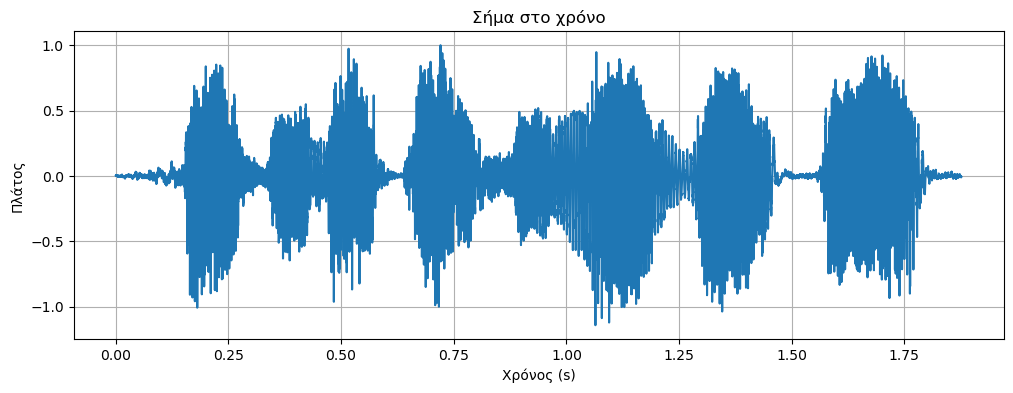

In [18]:
fs, s = wav.read('./files/military.wav')                   # Ανάγνωση
s = s/np.abs(np.max(s))                              # Κανονικοποίηση στο [-1, 1]
t = np.arange(0, len(s)/fs, 1/fs)                    # Άξονας χρόνου

plt.figure(figsize=(12,4))                           # Γράφημα
plt.plot(t, s)                                       # Περιεχόμενο 
plt.xlabel('Χρόνος (s)')                             # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                 # Ομορφαίνουμε
plt.grid()                                           # Ομορφαίνουμε
plt.title('Σήμα στο χρόνο')                          # Ομορφαίνουμε
plt.show()

Ας το ακούσουμε:

In [10]:
Audio(s, rate=fs)

**(θ.2')** Η έτοιμη συνάρτηση ``butter`` υλοποιεί διάφορα φίλτρα Butterworth με τάξη $N$ την οποία παρέχετε εσείς ως όρισμα, όπως και τη συχνότητα αποκοπής $f_c$, και επιστρέφει τους συντελεστές του αριθμητή και του παρονομαστή για το φίλτρο σας στο χώρο του Laplace (ή και του Fourier)! 

In [11]:
fc = 3000           # Συχνότητα αποκοπής
N = 30              # Ας επιλέξουμε τάξη ίση με 30 - ένα "αυστηρό" φίλτρο Butterworth με απότομη μετάβαση
b, a = butter(N=N, btype='low', Wn=fc, analog=False, output='ba', fs = fs)   # Δημιουργία φίλτρου

Παρατηρήστε ότι ζητήσαμε από τη συνάρτηση ``butter`` να μας φτιάξει ένα lowpass (χαμηλοπερατό) φίλτρο, τάξης $N$, με συχνότητα απόκοπής $W_n = f_c$, το φίλτρο μας να είναι $\textbf{ψηφιακό}$ κατευθείαν - θέτοντας $\texttt{analog=False}$ - και να μας δώσει ως έξοδο τους συντελεστές $b, a$ της συνάρτησης μεταφοράς του φίλτρου μας (που όμως, ως ψηφιακό φίλτρο, δεν ορίζεται στο χώρο του Laplace)! Το διάνυσμα των συντελεστών του αριθμητή θα είναι το $b$ ενώ του παρονομαστή θα είναι το $a$.

**(θ.3')** Δείτε την απόκριση συχνότητας $H(f)$ (μόνο για $f > 0$) του (ψηφιακού πλέον) φίλτρου σας με χρήση των εντολών:

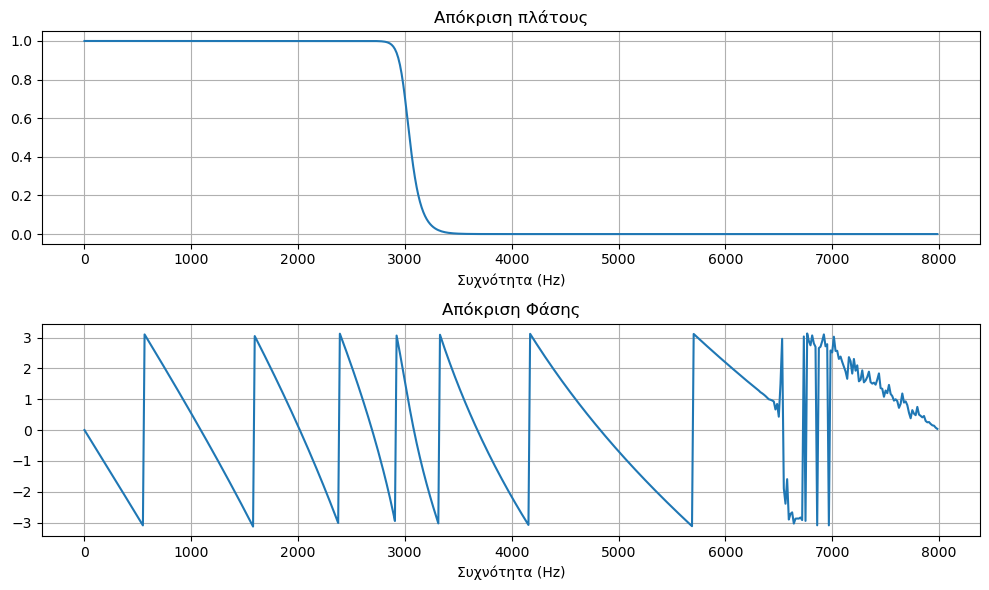

In [12]:
f, H = freqz(b=b, a=a, fs=fs)          # Καλούμε τη συνάρτηση freqz για να μας βρει την απόκριση σε συχνότητα H(f)

plt.figure(figsize=(10,6))             # Γράφημα

plt.subplot(2, 1, 1)                   # 2 γραμμές, 1 στήλη στο γράφημα: 1η γραμμή
plt.plot(f, np.abs(H))                 # Εμφάνιση απόκρισης πλάτους
plt.title('Απόκριση πλάτους')          # Ομορφαίνουμε      
plt.xlabel('Συχνότητα (Hz)')           # Ομορφαίνουμε
plt.grid(True)                         # Ομορφαίνουμε

plt.subplot(2, 1, 2)                   # 2 γραμμές, 1 στήλη στο γράφημα: 2η γραμμή
plt.plot(f, np.angle(H))               # Εμφάνιση απόκρισης φάσης
plt.title('Απόκριση Φάσης')            # Ομορφαίνουμε
plt.xlabel('Συχνότητα (Hz)')           # Ομορφαίνουμε
plt.grid(True)                         # Ομορφαίνουμε

plt.tight_layout()

**(θ.4')** Ας χρησιμοποιήσουμε τη συνάρτηση ``lfilter`` της βιβλιοθήκης ``SciPy`` για την υλοποίηση του συστήματος - είναι παρόμοια με την ``np.convolve`` που έχετε δει σε άλλο Εργαστήριο, απλά παίρνει διαφορετικά ορίσματα.

In [13]:
y = lfilter(b, a, x=s)       # Φιλτράρισμα (ουσιαστικά, συνέλιξη στο χρόνο του φίλτρου με το σήμα εισόδου)
y = y/np.abs(np.max(y))      # Κανονικοποίηση (δεν είναι κι απαραίτητο :) )

για να φιλτράρουμε το σήμα μέσα από το σύστημα που φτιάξαμε! Ας το ακούσουμε!

In [14]:
Audio(y, rate=fs) 

Συγκρίνετε με το αρχικό:

In [15]:
Audio(s, rate=fs)

Το ίδιο και οπτικά!

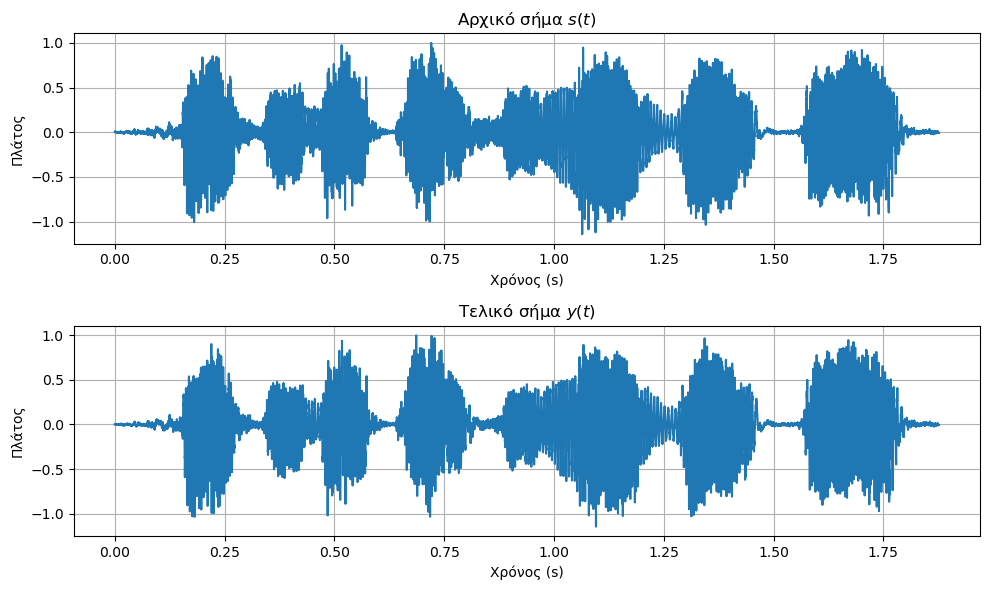

In [16]:
plt.figure(figsize=(10,6))                      # Γράφημα

plt.subplot(2, 1, 1)                            # 2 γραμμές, 1 στήλη στο γράφημα: 1η γραμμή
plt.plot(t, s)                                  # Περιεχόμενο 
plt.grid()
plt.title('Αρχικό σήμα $s(t)$')                 # Ομορφαίνουμε
plt.xlabel('Χρόνος (s)')                        # Ομορφαίνουμε
plt.ylabel('Πλάτος')                            # Ομορφαίνουμε

plt.subplot(2, 1, 2)                            # 2 γραμμές, 1 στήλη στο γράφημα: 2η γραμμή
plt.plot(t, y)                                  # Περιεχόμενο 
plt.grid()
plt.title('Τελικό σήμα $y(t)$')                 # Ομορφαίνουμε
plt.xlabel('Χρόνος (s)')                        # Ομορφαίνουμε
plt.ylabel('Πλάτος')                            # Ομορφαίνουμε

plt.tight_layout()
plt.show()
plt.close()

Από τα σήματα στο χρόνο, ίσως να δυσκολεύεστε να καταλάβετε τη διαφορά (θα πρέπει να κάνουμε zoom σε κάποια μέρη για να δούμε περισσότερη λεπτομέρεια). 

Ας δούμε τα δυο σήματα στη συχνότητα, εκτελώντας το Μετασχηματισμό Fourier για καθένα σήμα. Επειδή όμως τα σήματα ομιλίας, μουσικής, και γενικότερα τα πραγματικά ηχητικά σήματα, αλλάζουν πολύ γρήγορα όσο περνάει ο χρόνος, προτιμάμε να εκτελούμε το μετασχ. Fourier σε **τμήματα** (segments ή frames) σήματος, όπως το έχετε ήδη δει σε προηγούμενες σειρές Εργαστηρίων. 

Αντί όμως να τυπώσουμε ένα σωρό μετασχ. Fourier (καθώς τα σήματά μας περιέχουν πάρα πολλά τμήματα), καλύτερα να:
1. Χωρίσουμε το σήμα στα προαναφερθέντα τμήματα
2. Εκτελέσουμε το μετασχ. Fourier στο καθένα
3. Υπολογίσουμε το μέτρο του (δηλ. το φάσμα πλάτους)
4. Μαζέψουμε το αποτέλεσμα σε μια μεγάλη δομή (διδιάστατο πίνακα, π.χ.)
5. Τυπώσουμε όλα μαζί τα μέτρα των μετασχ. Fourier ως μια εικόνα, με άξονες $f$ και $t$, και το χρώμα κάθε pixel στις συντεταγμένες $(t_0, f_0)$ θα μας υποδηλώνει πόσο "δυνατό" είναι το μέτρο του μετασχηματισμού σε εκείνο το σημείο.

Το τελικό αποτέλεσμα ονομάζεται **φασματογράφημα (spectrogram)**. 

**ΕΥΤΥΧΩΣ** όλα αυτά τα κάνει η συνάρτηση ``specgram`` της βιβλιοθήκης απεικονίσεων ``matplotlib`` (μεταξύ πολλών άλλων βιβλιοθηκών που έχουν παρόμοιες συναρτήσεις), και σας δίνουμε όλο το σχετικό κώδικα έτοιμο. 

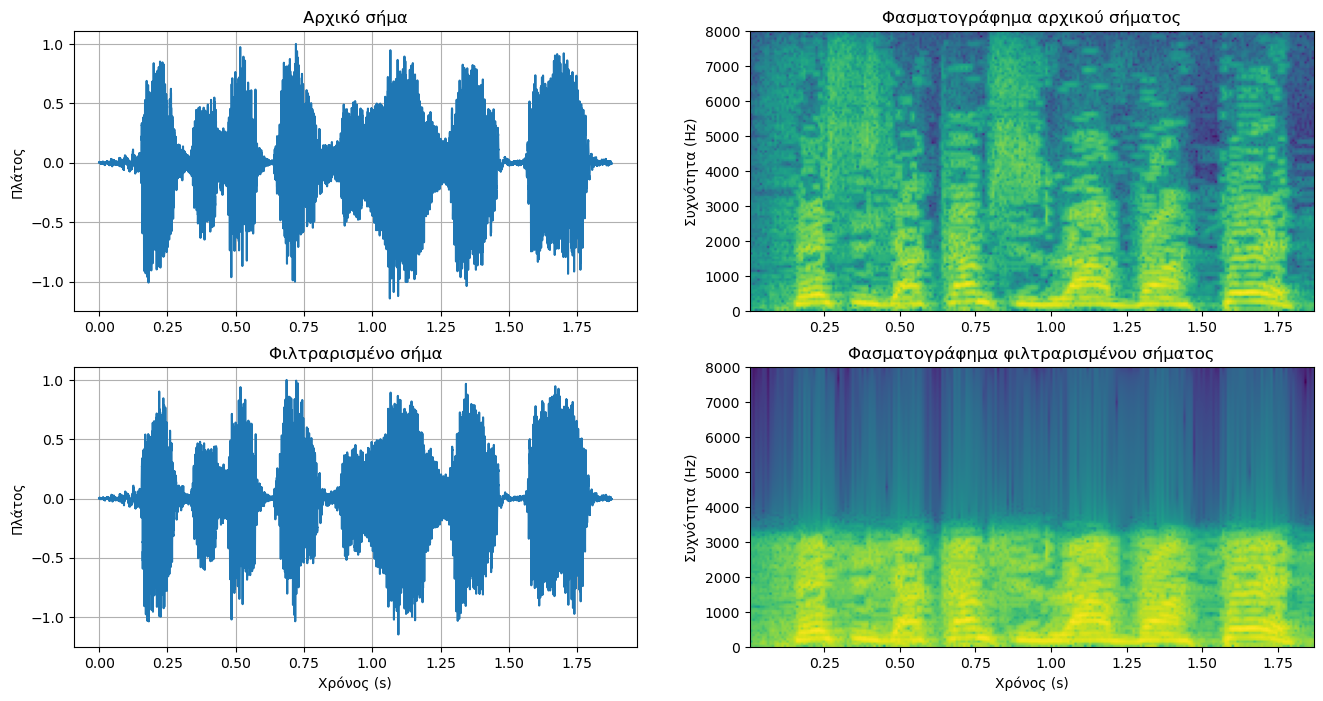

In [20]:
plt.figure(figsize=(16,8))

plt.subplot(2, 2, 1)
plt.title('Αρχικό σήμα')
plt.plot(t, s)
plt.grid()
plt.ylabel('Πλάτος')

plt.subplot(2, 2, 2)
plt.specgram(s, Fs=fs)
plt.title('Φασματογράφημα αρχικού σήματος')
plt.ylabel('Συχνότητα (Hz)')

plt.subplot(2, 2, 3)
plt.title('Φιλτραρισμένο σήμα')
plt.plot(t, y)
plt.grid()
plt.xlabel('Χρόνος (s)')
plt.ylabel('Πλάτος')

plt.subplot(2, 2, 4)
plt.specgram(y, Fs=fs)
plt.title('Φασματογράφημα φιλτραρισμένου σήματος')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Συχνότητα (Hz)')
plt.show()

Τι κερδίσαμε με το παραπάνω φιλτράρισμα? Το σήμα μας πλέον έχει **εύρος ζώνης (bandwidth)** περίπου ίσο με $3000$ Hz! (αντί του αρχικού, που ήταν $8000$ Hz). Άρα για να το μεταδώσουμε μέσα από ένα κανάλι χρειαζόμαστε το $1/4$ του αρχικού εύρους ζώνης. Αυτό σημαίνει ότι πληρώνουμε μικρότερο εύρος συχνοτήτων, άρα εξοικονομούμε χρήματα, χωρίς να αλλάζει το μήνυμα που φέρει το σήμα (πιστεύω ότι καταλαβαίνετε τις λέξεις στα σήματα και στις δυο περιπτώσεις).

$\LARGE \rightarrow$ Με βάση τόσο το ακουστικό αποτέλεσμα, όσο και τα παραπάνω σχήματα, **πώς θα χαρακτηρίζατε την ποιότητα του σήματος εξόδου σε σχέση με το αρχικό**; Σκεφτείτε πως επέδρασε το φίλτρο επάνω στις συχνότητες του σήματος εισόδου. Απαντήστε παρακάτω:

### Απάντηση:

Το σήμα έχει χάσει αρκετή από την ποιότητά του, είναι κατανοητό, αλλά οι υψηλές συχνότητες έχουν χαθεί.

---
---